# Clasificación de intenciones en español con BETO

**Procesamiento de Lenguaje Natural · ICESI**  
**Grupo:** X-Ray
**Integrantes:** Ruben Dario Sabogal · Cristian Camilo Quebrada · Edwin Perez L  
**Fecha:** 26 de septiembre de 2026

Una persona puede decir «pon una alarma para las siete» o «despiértame mañana a las siete»
y esperar la misma acción. En cambio, «¿qué alarmas tengo?» pide consultar, no crear.
Nuestro problema consiste en reconocer la **intención de una solicitud breve en español**.

Este notebook adapta el flujo del ejemplo de clase: datos → EDA → tokenizador → BETO
como extractor → clasificador más elaborado → ajuste completo → evaluación y errores.
El caso y los datos son diferentes a los de noticias del ejemplo.

**Objetivo del estudio:** comparar el desempeño y el costo de entrenamiento de TF-IDF,
BETO como extractor de representaciones y BETO con ajuste completo.

## 1. Problema, alcance y criterio de éxito

Un asistente necesita escoger la función a la que enviará una solicitud. Usaremos las
60 intenciones de MASSIVE: alarmas, calendario, música, clima y otras. Cada texto tiene
una etiqueta. El modelo **clasifica la solicitud**; no responde preguntas, ejecuta acciones
ni extrae los parámetros necesarios para realizarlas. Para una aplicación real haría
falta, por ejemplo, extraer la hora después de reconocer `alarm_set`.

Trabajamos con la versión `es-ES`, localizada al español de España. MASSIVE es un recurso
de investigación derivado de interacciones para asistentes; no asumimos que representa
todo el español colombiano ni conversaciones recientes. Esta limitación motiva nuestra
prueba final con expresiones propias y errores de escritura.

Compararemos cuatro enfoques sobre los mismos ejemplos:

| Enfoque | Qué aprende | Relación con la clase |
|---|---|---|
| TF-IDF + regresión logística | Relaciones entre palabras, bigramas e intención | Referencia adicional de bajo costo |
| BETO congelado + capa lineal | Un clasificador sobre representaciones fijas | Uso de BERT como extractor |
| BETO congelado + MLP | Relaciones no lineales sobre las mismas representaciones | Cabeza de clasificación más elaborada |
| BETO con fine-tuning | Representaciones y clasificador conjuntamente | Ajuste completo con Hugging Face Trainer |

La métrica principal será **F1 macro**, que da el mismo peso a cada intención con
ejemplos reales en la partición evaluada. Una clase sin soporte se marca como no evaluada.
También reportaremos accuracy, F1 ponderado, resultados por clase y tiempos. Elegiremos
configuraciones con validación; prueba se reservará para comparar los modelos finales.
No damos por hecho que el modelo más complejo será el mejor.

## 2. Preparación y reproducibilidad

La primera ejecución requiere conexión a Internet y espacio para los datos y los modelos.
La primera preparación descarga datos y BETO. Las siguientes ejecuciones pueden usar
esos archivos locales. Las revisiones y huellas SHA-256 se guardan en `data/fuentes.json`.
**Ejecución completa:** usa Python 3.11 e instala `requirements.txt` siguiendo el README.
`python scripts/ejecutar_notebook.py` ejecuta todas las celdas con un kernel nuevo y reentrena
los cuatro enfoques. Semilla y versiones no garantizan identidad numérica
entre CPU, CUDA y MPS; los tiempos también dependen del equipo.


In [1]:
import os
from pathlib import Path
ROOT = Path.cwd().resolve()
if not (ROOT / "requirements.txt").exists() and (ROOT / "proyecto-massive").exists():
    ROOT = ROOT / "proyecto-massive"
assert (ROOT / "requirements.txt").exists(), "Abre el notebook desde la carpeta del proyecto."
os.environ["HF_HOME"] = str(ROOT / ".cache" / "huggingface")
os.environ["HF_DATASETS_CACHE"] = str(ROOT / ".cache" / "datasets")
os.environ["MPLCONFIGDIR"] = str(ROOT / ".cache" / "matplotlib")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc, json, time, hashlib, platform, random, copy, unicodedata
import importlib.metadata as metadata
import numpy as np
import pandas as pd
from typing import Any, cast
from scipy.sparse import csr_matrix
pd.set_option("display.max_colwidth", 160)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import joblib
from IPython.display import display, Markdown
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from transformers import (AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, DataCollatorWithPadding, set_seed)
from datasets import Dataset

SEED = 42
#permite reentrenar el modelo si ya existe un modelo guardado
REENTRENAR = True
EPOCHS_FINE = 3
BATCH_FINE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
torch.set_num_threads(4)
set_seed(SEED)
OUT = ROOT / "resultados"
MODELS = ROOT / "modelos"
for folder in [OUT, MODELS, ROOT / ".cache"]:
    folder.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

def guardar_figura(nombre):
    plt.savefig(OUT / f"{nombre}.png", dpi=160, bbox_inches="tight")
    plt.show()

def sincronizar():
    if DEVICE == "mps": torch.mps.synchronize()
    elif DEVICE == "cuda": torch.cuda.synchronize()

versions = {p: metadata.version(p) for p in ["torch", "transformers", "accelerate", "datasets",
             "numpy", "pandas", "scikit-learn", "matplotlib"]}
environment = {"python": platform.python_version(), "platform": platform.platform(),
               "device": DEVICE, "seed": SEED, "versions": versions}
(OUT / "entorno.json").write_text(json.dumps(environment, indent=2))
print(f"Dispositivo: {DEVICE} | Python: {platform.python_version()} | Semilla: {SEED}")
display(pd.Series(versions, name="Versión").to_frame())

Matplotlib is building the font cache; this may take a moment.


Dispositivo: mps | Python: 3.11.16 | Semilla: 42


,Versión
torch,2.8.0
transformers,4.46.3
accelerate,1.1.1
datasets,3.1.0
numpy,2.1.3
pandas,2.2.3
scikit-learn,1.5.2
matplotlib,3.9.2


## 3. Datos y prevención de fugas

Fuente: [AmazonScience/MASSIVE](https://huggingface.co/datasets/AmazonScience/massive),
licencia **CC BY 4.0**. Usamos únicamente `utt` como entrada e `intent` como objetivo.
No introducimos `scenario`, anotaciones de slots ni juicios de los anotadores al modelo:
contienen información que no estaría disponible al recibir una solicitud nueva.

Conservamos las particiones oficiales. Auditamos texto vacío, etiquetas faltantes y
duplicados. Para comparar coincidencias normalizamos Unicode, espacios y mayúsculas;
los textos originales que recibe BETO mantienen sus tildes, signos y mayúsculas.

Política fijada antes de entrenar: conservamos prueba intacta; retiramos de validación
los textos presentes en prueba y de entrenamiento los presentes en cualquiera de las
dos particiones de evaluación. En entrenamiento quitamos grupos con etiquetas
contradictorias y repeticiones de texto. No trasladamos ejemplos entre particiones.
Así evitamos premiar la memorización de duplicados exactos. Este control no detecta
todas las paráfrasis ni prueba ausencia de contaminación del preentrenamiento.

In [2]:
import urllib.request
from huggingface_hub import snapshot_download

DATA_REVISION = "ed58ac423a2f4121720918bf5301577edce4ffd3"
MODEL_ID = "dccuchile/bert-base-spanish-wwm-cased"
MODEL_REVISION = "c4d86612f51b4f46759c8390d1798c2febe71b93"
EXPECTED_SHA256 = {
    "train": "e8f98e62b3ab88bbf974033647d79a44162bc555c559d0a8a0a201ccba596c0d",
    "validation": "c30e484522baf622329c740ca641fed1d5cb5f1f11dc877e49763e0bd1f8f92a",
    "test": "ca94eebc836e61e8bc530966c6565bb2c2b9d6184cc910c767c7fa6a9563de19",
}

# La preparación está integrada: no se necesitan scripts externos.
def preparar_fuentes():
    (ROOT / "data").mkdir(exist_ok=True)
    files = {}
    for split in ["train", "validation", "test"]:
        url = f"https://huggingface.co/datasets/AmazonScience/massive/resolve/{DATA_REVISION}/es-ES/{split}/0000.parquet"
        path = ROOT / "data" / f"{split}.parquet"
        if not path.exists():
            print(f"Descargando datos: {split}")
            temporary = path.with_suffix(".part")
            urllib.request.urlretrieve(url, temporary)
            assert hashlib.sha256(temporary.read_bytes()).hexdigest() == EXPECTED_SHA256[split], "La descarga no coincide con la fuente fijada."
            temporary.replace(path)
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        assert digest == EXPECTED_SHA256[split], f"Revisa la integridad de {path.name}."
        files[split] = {"url": url, "sha256": digest}
    base = MODELS / "beto_base"
    required = ["config.json", "tokenizer.json", "tokenizer_config.json", "special_tokens_map.json", "vocab.txt", "pytorch_model.bin"]
    if not all((base / name).exists() for name in required):
        print("Descargando el checkpoint base de BETO...")
        snapshot_download(MODEL_ID, revision=MODEL_REVISION, local_dir=base, allow_patterns=required)
    manifest = {"dataset": "AmazonScience/massive", "locale": "es-ES", "dataset_revision": DATA_REVISION,
                "license": "CC BY 4.0", "files": files, "model": MODEL_ID, "model_revision": MODEL_REVISION,
                "dataset_source": "https://huggingface.co/datasets/AmazonScience/massive",
                "model_source": f"https://huggingface.co/{MODEL_ID}"}
    (ROOT / "data/fuentes.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
    return manifest

manifest = preparar_fuentes()
import pyarrow.parquet as pq
arrow_meta = json.loads(pq.read_schema(ROOT / "data/train.parquet").metadata[b"huggingface"])
features = arrow_meta["info"]["features"]
LABELS = features["intent"]["names"]
SCENARIOS = features["scenario"]["names"]
N_CLASSES = len(LABELS)
id2label = dict(enumerate(LABELS))
label2id = {v: k for k, v in id2label.items()}
raw = {}
for split in ["train", "validation", "test"]:
    path = ROOT / "data" / f"{split}.parquet"
    assert hashlib.sha256(path.read_bytes()).hexdigest() == manifest["files"][split]["sha256"]
    frame = pd.read_parquet(path)[["id", "utt", "intent", "scenario"]].copy()
    assert frame[["utt", "intent"]].notna().all().all()
    assert frame["utt"].str.strip().ne("").all()
    frame["key"] = frame.utt.map(lambda s: " ".join(unicodedata.normalize("NFKC", str(s)).casefold().split()))
    assert frame.intent.between(0, N_CLASSES - 1).all()
    raw[split] = frame

clean = {"test": raw["test"].copy()}
clean["validation"] = raw["validation"].loc[~raw["validation"].key.isin(clean["test"].key)].copy()
clean["validation"] = clean["validation"].drop_duplicates("key")
excluded_keys = set(clean["test"].key) | set(clean["validation"].key)
train = raw["train"].loc[~raw["train"].key.isin(excluded_keys)].copy()
conflicting = train.groupby("key").intent.nunique()
train = train.loc[~train.key.isin(conflicting[conflicting > 1].index)]
clean["train"] = train.drop_duplicates("key").copy()
for split in clean:
    clean[split] = clean[split].reset_index(drop=True)
    clean[split]["intencion"] = clean[split].intent.map(id2label)
    clean[split].to_csv(OUT / f"particion_{split}.csv", index=False)
assert not (set(clean["train"].key) & set(clean["validation"].key))
assert not (set(clean["train"].key) & set(clean["test"].key))
assert not (set(clean["validation"].key) & set(clean["test"].key))
assert set(clean["train"].intent) == set(range(N_CLASSES))
audit = pd.DataFrame([{"partición": s, "originales": len(raw[s]), "utilizados": len(clean[s]),
                       "retirados": len(raw[s])-len(clean[s]),
                       "textos_repetidos_originales": int(raw[s].key.duplicated().sum())}
                      for s in ["train", "validation", "test"]])
audit.to_csv(OUT / "auditoria_datos.csv", index=False)
display(audit)
display(clean["train"][["utt", "intencion"]].sample(8, random_state=SEED))
print(f"{N_CLASSES} intenciones. No hay textos normalizados compartidos entre particiones.")

,partición,originales,utilizados,retirados,textos_repetidos_originales
0,train,11514,10957,557,344
1,validation,2033,1976,57,18
2,test,2974,2974,0,30


,utt,intencion
3543,va a estar soleado hoy,weather_query
927,pon la ultima cancion de mi lista de reproduccion mas reciente,play_music
6761,tengo que añadir leche a la lista de la compra,lists_query
9171,encuentra la tasa de cambio de dólar para dólar americano,qa_currency
7563,hay algún evento divertido en barcelona hoy,recommendation_events
10720,yo tengo algún correo electrónico de marta,email_query
7229,podrías por favor poner el siguiente episodio del podcast,play_podcasts
5683,evento,calendar_set


60 intenciones. No hay textos normalizados compartidos entre particiones.


## 4. Análisis exploratorio del entrenamiento

Exploramos principalmente entrenamiento para no orientar las decisiones con prueba.
Nos interesa saber si hay clases minoritarias, cuánto varían las solicitudes y si
podemos evitar secuencias innecesariamente largas. Una intención con pocos ejemplos
puede tener un F1 inestable aunque la accuracy global parezca buena.

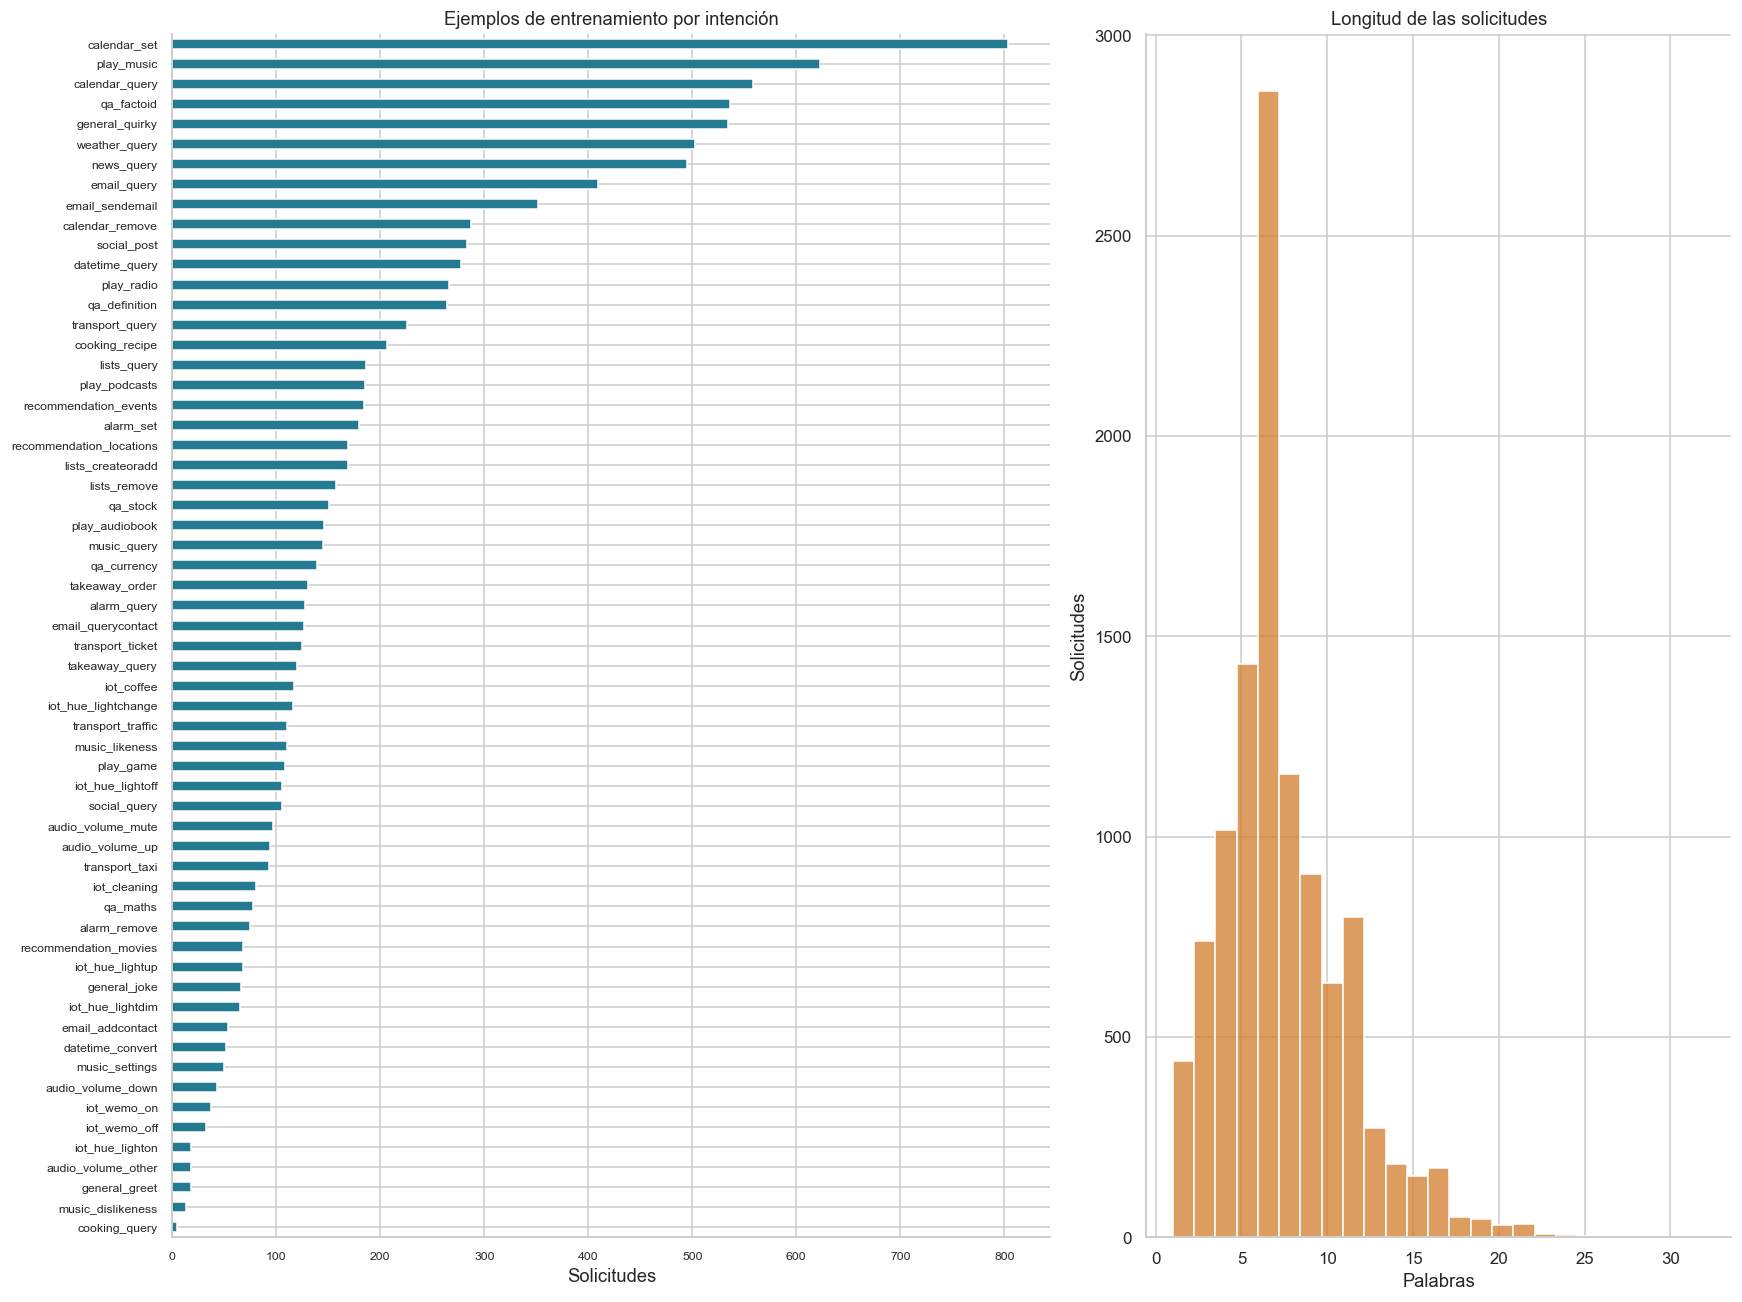

,palabras,caracteres
count,10957.0,10957.0
mean,7.4,40.5
std,3.6,19.4
min,1.0,2.0
50%,7.0,37.0
90%,12.0,65.0
95%,14.0,77.0
99%,19.0,103.4
max,32.0,205.0


La intención más frecuente es **calendar_set**, con **804** textos; la menos frecuente es **cooking_query**, con **4**. La relación es **201.0:1**. La mediana es **7 palabras**. Por eso compararemos F1 macro además de accuracy y elegiremos la longitud con tokens reales.

In [3]:
train_df = clean["train"].copy()
train_df["palabras"] = train_df.utt.str.split().str.len()
train_df["caracteres"] = train_df.utt.str.len()
counts = train_df.intencion.value_counts()
fig, axes = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={"width_ratios": [1.5, 1]})
counts.sort_values().plot.barh(ax=axes[0], color="#247B91", fontsize=8)
axes[0].set(title="Ejemplos de entrenamiento por intención", xlabel="Solicitudes", ylabel="")
sns.histplot(train_df.palabras, bins=25, ax=axes[1], color="#D27C2C")
axes[1].set(title="Longitud de las solicitudes", xlabel="Palabras", ylabel="Solicitudes")
plt.tight_layout()
guardar_figura("eda_clases_longitud")
display(train_df[["palabras", "caracteres"]].describe(percentiles=[.5, .9, .95, .99]).round(1))
display(Markdown(f"La intención más frecuente es **{counts.index[0]}**, con **{counts.iloc[0]}** textos; "
                 f"la menos frecuente es **{counts.index[-1]}**, con **{counts.iloc[-1]}**. "
                 f"La relación es **{counts.iloc[0]/counts.iloc[-1]:.1f}:1**. "
                 f"La mediana es **{train_df.palabras.median():.0f} palabras**. "
                 "Por eso compararemos F1 macro además de accuracy y elegiremos la longitud con tokens reales."))

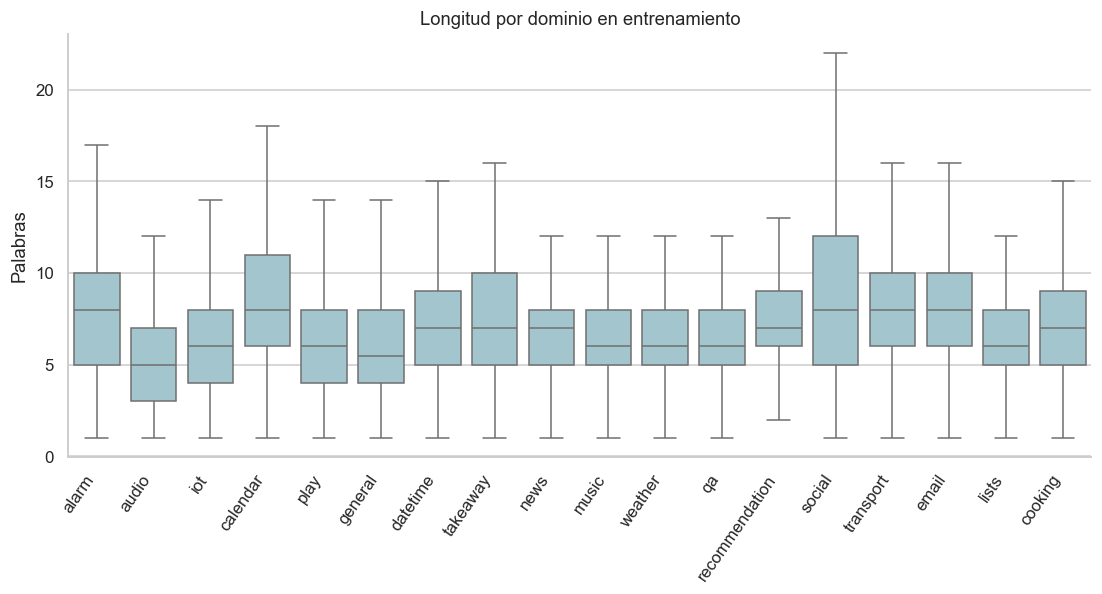

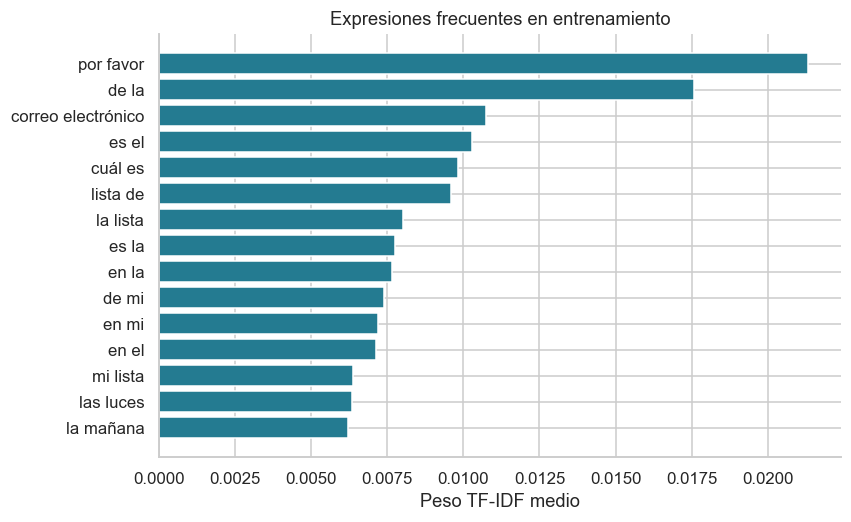

In [4]:
train_df["dominio"] = train_df.scenario.map(dict(enumerate(SCENARIOS)))
plt.figure(figsize=(12, 5))
sns.boxplot(data=train_df, x="dominio", y="palabras", showfliers=False, color="#9CCAD5")
plt.xticks(rotation=55, ha="right")
plt.title("Longitud por dominio en entrenamiento")
plt.xlabel(""); plt.ylabel("Palabras")
guardar_figura("eda_dominios")

# N-gramas frecuentes: describen el corpus, no demuestran causalidad.
eda_vectorizer = TfidfVectorizer(ngram_range=(2, 2), min_df=3, max_features=5000)
eda_x = csr_matrix(eda_vectorizer.fit_transform(train_df.utt))
terms = np.asarray(eda_vectorizer.get_feature_names_out())
mean_weights = np.asarray(eda_x.mean(axis=0)).ravel()
idx = mean_weights.argsort()[-15:]
plt.figure(figsize=(8, 5))
plt.barh(terms[idx], mean_weights[idx], color="#247B91")
plt.xlabel("Peso TF-IDF medio"); plt.title("Expresiones frecuentes en entrenamiento")
guardar_figura("eda_expresiones")

**Lectura del EDA.** La cantidad total de datos oculta diferencias fuertes entre
intenciones. Después de la limpieza, `cooking_query` tiene solo cuatro ejemplos de
entrenamiento. Por eso, disponer de miles de solicitudes no significa que todas las
clases estén bien representadas. Los pares de palabras frecuentes pueden ayudar a
reconocer acciones, pero expresiones como «qué tengo» necesitan contexto para distinguir
calendario, alarmas o listas. Esta es una razón concreta para comparar TF-IDF con BETO.

No eliminamos clases difíciles para mejorar la cifra global. Conservamos el problema
original, mostramos los soportes y reconocemos dónde faltan datos. Una siguiente
iteración debería priorizar ejemplos de las categorías minoritarias.

## 5. Tokenizador de BETO y longitud de entrada

Usamos el mismo tokenizador y checkpoint de BETO que el ejemplo. Un token puede ser
una palabra, parte de una palabra o un signo. Por eso no equiparamos palabras y tokens.
Elegimos el percentil 99 de longitud del entrenamiento, redondeado a un múltiplo de 8,
con mínimo 16 y máximo 128. Es una regla práctica para textos breves, fijada sin mirar prueba.
Mediremos la fracción truncada. El padding dinámico completa cada lote hasta su texto
más largo y evita rellenar todos los ejemplos hasta 512 posiciones.

Longitud máxima elegida: 24 tokens
Percentiles 50, 95 y 99: [10. 19. 24.]
Entrenamiento truncado: 0.92%
Ejemplo de tokenización: ['Recu', '##ér', '##dame', 'llamar', 'a', 'Rubén', 'mañana', 'a', 'las', 'ocho', '.']


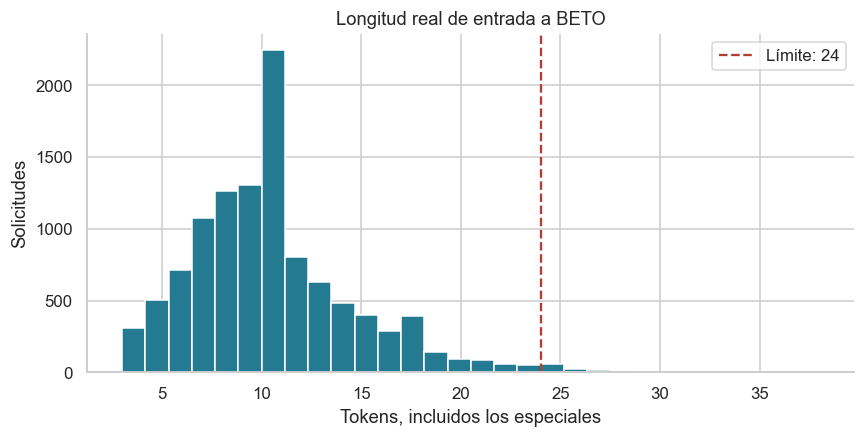

In [5]:
BASE = MODELS / "beto_base"
tokenizer = AutoTokenizer.from_pretrained(BASE, local_files_only=True)
train_token_lengths = np.array([len(x) for x in tokenizer(train_df.utt.tolist(), truncation=False)["input_ids"]])
MAX_LEN = int(min(128, max(16, 8 * np.ceil(np.quantile(train_token_lengths, .99) / 8))))
print("Longitud máxima elegida:", MAX_LEN, "tokens")
print("Percentiles 50, 95 y 99:", np.quantile(train_token_lengths, [.5,.95,.99]))
print(f"Entrenamiento truncado: {(train_token_lengths > MAX_LEN).mean():.2%}")
print("Ejemplo de tokenización:", tokenizer.tokenize("Recuérdame llamar a Rubén mañana a las ocho."))
plt.figure(figsize=(9, 4))
plt.hist(train_token_lengths, bins=30, color="#247B91")
plt.axvline(MAX_LEN, color="#B33D35", linestyle="--", label=f"Límite: {MAX_LEN}")
plt.xlabel("Tokens, incluidos los especiales"); plt.ylabel("Solicitudes")
plt.title("Longitud real de entrada a BETO"); plt.legend()
guardar_figura("eda_tokens")

y = {s: clean[s].intent.to_numpy() for s in clean}
def metricas(real, pred):
    return {"accuracy": accuracy_score(real, pred),
            "f1_macro": f1_score(real, pred, labels=np.unique(real), average="macro", zero_division=0),
            "f1_ponderado": f1_score(real, pred, labels=range(N_CLASSES), average="weighted", zero_division=0)}

validation_records = []
training_cost = {}

## 6. Referencia: TF-IDF y regresión logística

Este modelo aprende qué palabras y pares de palabras se asocian con cada intención.
Es una referencia útil: si obtiene resultados cercanos a BETO con menor costo, conviene
reconocerlo. Probamos dos valores de regularización (`C=1` y `C=4`) usando validación.
El vocabulario y los pesos IDF se ajustan exclusivamente con entrenamiento.

In [6]:
tfidf_path = MODELS / "tfidf.joblib"
tfidf_meta_path = OUT / "tfidf_entrenamiento.json"
if REENTRENAR or not tfidf_path.exists():
    start = time.perf_counter()
    candidates = []
    best_score = -1
    for c in [1.0, 4.0]:
        candidate = Pipeline([
            ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True, max_features=40000)),
            ("clasificador", LogisticRegression(C=c, max_iter=500, random_state=SEED))])
        candidate.fit(clean["train"].utt, y["train"])
        score = metricas(y["validation"], candidate.predict(clean["validation"].utt))
        candidates.append({"modelo": "TF-IDF + lineal", "configuración": f"C={c}", **score})
        if score["f1_macro"] > best_score:
            best_score, tfidf = score["f1_macro"], candidate
    tfidf_info = {"segundos_busqueda": time.perf_counter()-start, "candidatos": candidates}
    joblib.dump(tfidf, tfidf_path)
    tfidf_meta_path.write_text(json.dumps(tfidf_info, indent=2))
else:
    tfidf = joblib.load(tfidf_path)
    tfidf_info = json.loads(tfidf_meta_path.read_text())
validation_records.extend(tfidf_info["candidatos"])
training_cost["TF-IDF + lineal"] = tfidf_info["segundos_busqueda"]
display(pd.DataFrame(tfidf_info["candidatos"]))

,modelo,configuración,accuracy,f1_macro,f1_ponderado
0,TF-IDF + lineal,C=1.0,0.763158,0.690098,0.765619
1,TF-IDF + lineal,C=4.0,0.794534,0.756000,0.797367


## 7. BETO congelado: extraer una vez, comparar dos cabezas

Como en clase, mantenemos fijos los parámetros del codificador. Calculamos una
representación de 768 componentes por solicitud mediante la media de los estados de
los tokens válidos (sin padding ni tokens especiales). Este **mean pooling** es una
variación respecto al clasificador del ejemplo, que usa la salida agrupada de BERT.

Guardamos las representaciones para evitar repetir el codificador en cada época.
BETO permanece en `eval()`, sin dropout, y no recibe gradientes. Sobre los mismos
vectores entrenamos una capa lineal y una MLP con una capa oculta, ReLU y dropout.
Esta separación conserva la idea de las dos cabezas de clase y reduce el costo local.

In [7]:
encoder = AutoModel.from_pretrained(
    BASE,
    local_files_only=True,
    add_pooling_layer=False
).to(DEVICE)
encoder.eval()
for parameter in encoder.parameters():
    parameter.requires_grad = False
print("Parámetros del codificador:", sum(p.numel() for p in encoder.parameters()))
print("Parámetros entrenables del codificador:", sum(p.numel() for p in encoder.parameters() if p.requires_grad))

def extraer_vectores(texts, batch_size=32):
    values = []
    with torch.inference_mode():
        for start in range(0, len(texts), batch_size):
            batch = tokenizer(texts[start:start+batch_size], padding=True, truncation=True,
                              max_length=MAX_LEN, return_tensors="pt", return_special_tokens_mask=True)
            special = batch.pop("special_tokens_mask").to(DEVICE)
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            hidden = encoder(**batch).last_hidden_state
            mask = (batch["attention_mask"] * (1-special)).unsqueeze(-1)
            pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1)
            values.append(pooled.cpu().numpy())
    return np.concatenate(values)

# La clave de caché incluye textos, orden, modelo y longitud; evita reutilizar vectores incompatibles.
embeddings = {}
embedding_times = {}
for split in ["train", "validation"]:
    content = json.dumps([manifest["model_revision"], MAX_LEN, clean[split].utt.tolist()], ensure_ascii=False)
    fingerprint = hashlib.sha256(content.encode()).hexdigest()[:16]
    cache = ROOT / ".cache" / f"embeddings_{split}_{fingerprint}.npz"
    if cache.exists():
        saved = np.load(cache)
        embeddings[split] = saved["x"]
        embedding_times[split] = float(saved["seconds"])
        print(split, "representaciones verificadas por clave de caché", embeddings[split].shape)
    else:
        start = time.perf_counter()
        embeddings[split] = extraer_vectores(clean[split].utt.tolist())
        sincronizar()
        embedding_times[split] = time.perf_counter()-start
        np.savez_compressed(cache, x=embeddings[split], seconds=embedding_times[split])
        print(split, embeddings[split].shape, f"{embedding_times[split]:.1f} segundos")

Parámetros del codificador: 109260288
Parámetros entrenables del codificador: 0


train (10957, 768) 23.3 segundos


validation (1976, 768) 3.9 segundos


BETO congelado + lineal parámetros entrenables: 46140 mejor época: 23 F1 macro: 0.7775


BETO congelado + MLP parámetros entrenables: 212284 mejor época: 19 F1 macro: 0.782


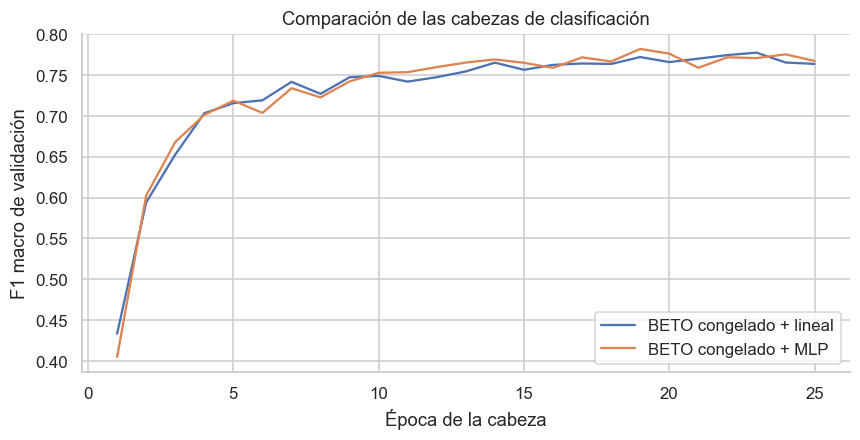

In [8]:
def construir_cabeza(hidden=0):
    if hidden == 0:
        return nn.Linear(768, N_CLASSES)
    return nn.Sequential(nn.Linear(768, hidden), nn.ReLU(), nn.Dropout(.2), nn.Linear(hidden, N_CLASSES))

def probabilidades_cabeza(head, x):
    head.eval()
    with torch.inference_mode():
        return torch.softmax(head(torch.tensor(x, dtype=torch.float32)), dim=-1).numpy()

def entrenar_cabeza(hidden, epochs=25):
    # Las cabezas pequeñas se entrenan en CPU; las representaciones ya están calculadas.
    set_seed(SEED)
    head = construir_cabeza(hidden)
    optimizer = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=.01)
    dataset = torch.utils.data.TensorDataset(torch.tensor(embeddings["train"], dtype=torch.float32),
                                            torch.tensor(y["train"], dtype=torch.long))
    loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True,
                                         generator=torch.Generator().manual_seed(SEED))
    best_score, best_state, history = -1, None, []
    for epoch in range(1, epochs+1):
        head.train()
        losses = []
        for xbatch, ybatch in loader:
            optimizer.zero_grad()
            # CrossEntropyLoss recibe logits, sin aplicar LogSoftmax antes.
            loss = nn.functional.cross_entropy(head(xbatch), ybatch)
            loss.backward(); optimizer.step()
            losses.append(loss.item())
        pred = probabilidades_cabeza(head, embeddings["validation"]).argmax(1)
        scores = metricas(y["validation"], pred)
        history.append({"epoch": epoch, "loss": np.mean(losses), **scores})
        if scores["f1_macro"] > best_score:
            best_score, best_state = scores["f1_macro"], copy.deepcopy(head.state_dict())
    assert best_state is not None, "No se seleccionó una época válida."
    head.load_state_dict(best_state)
    return head, history

heads, head_histories = {}, {}
for name, hidden in [("BETO congelado + lineal", 0), ("BETO congelado + MLP", 256)]:
    filename = "cabeza_lineal" if hidden == 0 else "cabeza_mlp"
    path, meta_path = MODELS / f"{filename}.pt", OUT / f"{filename}.json"
    if REENTRENAR or not path.exists():
        start = time.perf_counter()
        head, history = entrenar_cabeza(hidden)
        info = {"segundos_cabeza": time.perf_counter()-start, "history": history, "hidden": hidden}
        torch.save(head.state_dict(), path)
        meta_path.write_text(json.dumps(info, indent=2))
    else:
        info = json.loads(meta_path.read_text())
        head = construir_cabeza(hidden)
        head.load_state_dict(torch.load(path, map_location="cpu", weights_only=True))
    heads[name], head_histories[name] = head, info["history"]
    # Cada alternativa incluye el costo del extractor; los vectores se compartieron en esta ejecución.
    training_cost[name] = info["segundos_cabeza"] + sum(embedding_times.values())
    best = max(info["history"], key=lambda r: r["f1_macro"])
    validation_records.append({"modelo": name, "configuración": f"época={best['epoch']}; oculta={hidden}",
                               **{k: best[k] for k in ["accuracy", "f1_macro", "f1_ponderado"]}})
    print(name, "parámetros entrenables:", sum(p.numel() for p in head.parameters()),
          "mejor época:", best["epoch"], "F1 macro:", round(best["f1_macro"],4))

plt.figure(figsize=(9, 4))
for name, history in head_histories.items():
    frame = pd.DataFrame(history)
    plt.plot(frame.epoch, frame.f1_macro, label=name)
plt.xlabel("Época de la cabeza"); plt.ylabel("F1 macro de validación")
plt.title("Comparación de las cabezas de clasificación"); plt.legend()
guardar_figura("aprendizaje_cabezas")
# Liberamos el codificador congelado antes de entrenar el modelo completo.
encoder.to("cpu")
del encoder
gc.collect()
if DEVICE == "mps": torch.mps.empty_cache()

## 8. Fine-tuning de BETO con Trainer

Ahora permitimos que todo BETO aprenda la tarea. Partimos de nuevo del checkpoint base,
no de los pesos de otro experimento. Usamos tres épocas, tasa de aprendizaje `3e-5`,
regularización y calentamiento inicial. `Trainer` evalúa cada época y recupera la de
mayor F1 macro de validación. No ajustamos parámetros observando prueba.

El presupuesto es deliberadamente acotado para ejecutar el estudio en un computador.
Tres épocas son un experimento concreto, no una garantía de convergencia ni el máximo
rendimiento posible. La comparación con las cabezas congeladas también cambia el
pooling y el presupuesto: no es una ablación que aísle únicamente congelar parámetros.

In [9]:
def tokenizar_particion(split):
    ds = Dataset.from_dict({"text": clean[split].utt.tolist(), "labels": y[split].tolist()})
    return ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=MAX_LEN),
                  batched=True, remove_columns=["text"])

tokenized = {s: tokenizar_particion(s) for s in ["train", "validation"]}
collator = DataCollatorWithPadding(tokenizer, pad_to_multiple_of=8)
fine_path = MODELS / "beto_finetuning"
fine_meta_path = OUT / "finetuning.json"

def compute_metrics(pred):
    return metricas(pred.label_ids, pred.predictions.argmax(-1))

args = TrainingArguments(
    output_dir=str(ROOT / ".cache" / "checkpoints"),
    num_train_epochs=EPOCHS_FINE, learning_rate=3e-5,
    per_device_train_batch_size=BATCH_FINE, per_device_eval_batch_size=32,
    weight_decay=.01, warmup_ratio=.1, eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
    save_total_limit=1, logging_steps=100, seed=SEED, data_seed=SEED,
    report_to="none", dataloader_num_workers=0, dataloader_pin_memory=False,
    fp16=False, bf16=False, optim="adamw_torch", disable_tqdm=True)

set_seed(SEED)
if REENTRENAR or not (fine_path / "config.json").exists():
    fine_model = AutoModelForSequenceClassification.from_pretrained(
        BASE, num_labels=N_CLASSES, id2label=id2label, label2id=label2id, local_files_only=True)
    trainer = Trainer(model=fine_model, args=args, train_dataset=tokenized["train"],
                      eval_dataset=tokenized["validation"], data_collator=collator,
                      processing_class=tokenizer, compute_metrics=compute_metrics)
    start = time.perf_counter()
    trainer.train()
    sincronizar()
    fine_info = {"segundos": time.perf_counter()-start, "history": trainer.state.log_history,
                 "best_metric": trainer.state.best_metric,
                 "parámetros_entrenables": sum(p.numel() for p in fine_model.parameters() if p.requires_grad)}
    trainer.save_model(str(fine_path))
    tokenizer.save_pretrained(fine_path)
    fine_meta_path.write_text(json.dumps(fine_info, indent=2))
else:
    fine_model = AutoModelForSequenceClassification.from_pretrained(fine_path, local_files_only=True)
    trainer = Trainer(model=fine_model, args=args, eval_dataset=tokenized["validation"], data_collator=collator,
                      processing_class=tokenizer, compute_metrics=compute_metrics)
    fine_info = json.loads(fine_meta_path.read_text())

# Trainer acepta Dataset de Hugging Face; su anotación estática solo declara Dataset de PyTorch.
fine_val = trainer.predict(cast(Any, tokenized["validation"]))
fine_val_scores = metricas(y["validation"], np.asarray(fine_val.predictions).argmax(1))
validation_records.append({"modelo": "BETO fine-tuning", "configuración": "lr=3e-5; mejor de 3 épocas", **fine_val_scores})
training_cost["BETO fine-tuning"] = fine_info["segundos"]
val_table = pd.DataFrame(validation_records)
val_table.to_csv(OUT / "comparacion_validacion.csv", index=False)
display(val_table.round(4))
winner_name = val_table.sort_values("f1_macro", ascending=False).iloc[0]["modelo"]
print("Modelo elegido por validación:", winner_name)

Map:   0%|          | 0/10957 [00:00<?, ? examples/s]

Map:   0%|          | 0/1976 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /private/tmp/massive-verificacion/modelos/beto_base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'loss': 3.9309, 'grad_norm': 6.886520862579346, 'learning_rate': 1.4563106796116505e-05, 'epoch': 0.145985401459854}


{'loss': 3.0224, 'grad_norm': 9.323555946350098, 'learning_rate': 2.912621359223301e-05, 'epoch': 0.291970802919708}


...

{'loss': 0.2804, 'grad_norm': 0.8455213308334351, 'learning_rate': 8.923742563547863e-07, 'epoch': 2.9197080291970803}


{'eval_loss': 0.5697526931762695, 'eval_accuracy': 0.8699392712550608, 'eval_f1_macro': 0.8137331738465564, 'eval_f1_ponderado': 0.8668658698933254, 'eval_runtime': 8.1349, 'eval_samples_per_second': 242.904, 'eval_steps_per_second': 7.621, 'epoch': 3.0}


{'train_runtime': 648.3246, 'train_samples_per_second': 50.701, 'train_steps_per_second': 3.17, 'train_loss': 0.9120625178019206, 'epoch': 3.0}


,modelo,configuración,accuracy,f1_macro,f1_ponderado
0,TF-IDF + lineal,C=1.0,0.7632,0.6901,0.7656
1,TF-IDF + lineal,C=4.0,0.7945,0.7560,0.7974
2,BETO congelado + lineal,época=23; oculta=0,0.8112,0.7775,0.8112
3,BETO congelado + MLP,época=19; oculta=256,0.8153,0.7820,0.8144
4,BETO fine-tuning,lr=3e-5; mejor de 3 épocas,0.8699,0.8137,0.8669


Modelo elegido por validación: BETO fine-tuning


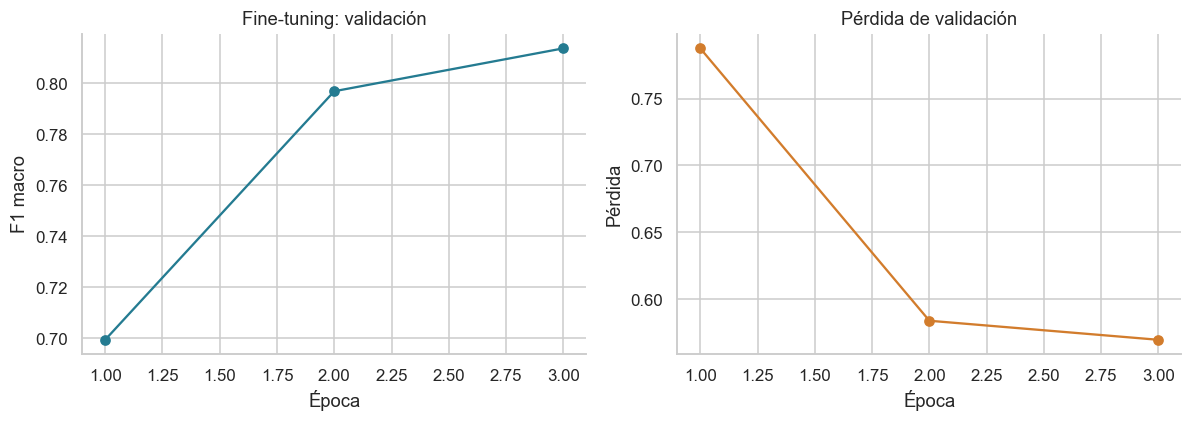

In [10]:
fine_history = pd.DataFrame([r for r in fine_info["history"] if "eval_f1_macro" in r])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fine_history.epoch, fine_history.eval_f1_macro, marker="o", color="#247B91")
axes[0].set(xlabel="Época", ylabel="F1 macro", title="Fine-tuning: validación")
axes[1].plot(fine_history.epoch, fine_history.eval_loss, marker="o", color="#D27C2C")
axes[1].set(xlabel="Época", ylabel="Pérdida", title="Pérdida de validación")
plt.tight_layout(); guardar_figura("aprendizaje_finetuning")

## 9. Efecto de la cantidad de datos

Para responder a nuestra motivación inicial, entrenamos la referencia TF-IDF con el
25 %, 50 % y 100 % del entrenamiento limpio. Conservamos la proporción de clases y
medimos siempre sobre la misma validación. Esta curva estudia el efecto de la cantidad
de datos para **ese modelo**; no permite extrapolar automáticamente el comportamiento
de BETO ni sustituye una repetición con varias semillas.

,fracción,ejemplos,accuracy,f1_macro,f1_ponderado
0,0.25,2739,0.7045,0.6331,0.7037
1,0.50,5478,0.7692,0.7195,0.7712
2,1.00,10957,0.7945,0.7560,0.7974


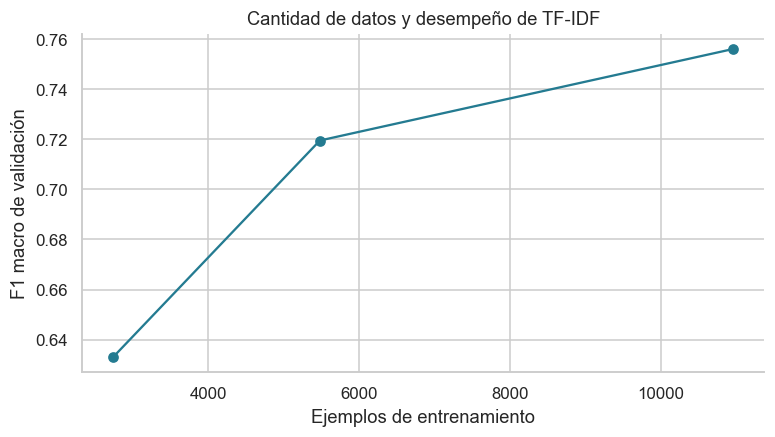

In [11]:
learning_rows = []
selected_c = tfidf.named_steps["clasificador"].C
for fraction in [.25, .5, 1.0]:
    if fraction < 1:
        indices, _ = train_test_split(np.arange(len(y["train"])), train_size=fraction,
                                      stratify=y["train"], random_state=SEED)
        reduced = Pipeline([
            ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True, max_features=40000)),
            ("clasificador", LogisticRegression(C=selected_c, max_iter=500, random_state=SEED))])
        reduced.fit(clean["train"].utt.iloc[indices], y["train"][indices])
    else:
        indices, reduced = np.arange(len(y["train"])), tfidf
    learning_rows.append({"fracción": fraction, "ejemplos": len(indices),
                          **metricas(y["validation"], reduced.predict(clean["validation"].utt))})
learning_table = pd.DataFrame(learning_rows)
learning_table.to_csv(OUT / "curva_cantidad_datos.csv", index=False)
display(learning_table.round(4))
plt.figure(figsize=(8,4))
plt.plot(learning_table.ejemplos, learning_table.f1_macro, marker="o", color="#247B91")
plt.xlabel("Ejemplos de entrenamiento"); plt.ylabel("F1 macro de validación")
plt.title("Cantidad de datos y desempeño de TF-IDF")
guardar_figura("curva_cantidad_datos")

### Fijar la regla de aclaración antes de abrir prueba
Seleccionamos el umbral exclusivamente con validación. La sección 12 analiza luego
su cobertura y sus aciertos en prueba, sin modificar esta decisión.

In [12]:
if winner_name == "BETO fine-tuning":
    val_probs = torch.softmax(torch.tensor(fine_val.predictions), -1).numpy()
elif winner_name in heads:
    val_probs = probabilidades_cabeza(heads[winner_name], embeddings["validation"])
else:
    val_probs = tfidf.predict_proba(clean["validation"].utt)
threshold_rows = []
for threshold in np.round(np.arange(0, 1, .05), 2):
    accepted = val_probs.max(1) >= threshold
    n = int(accepted.sum())
    threshold_rows.append({"umbral": float(threshold), "aceptados": n, "cobertura": accepted.mean(),
                           "accuracy_aceptados": accuracy_score(y["validation"][accepted], val_probs[accepted].argmax(1)) if n else np.nan})
threshold_table = pd.DataFrame(threshold_rows)
eligible = threshold_table.query("accuracy_aceptados >= .90 and aceptados >= 50")
THRESHOLD = float(eligible.sort_values("cobertura", ascending=False).iloc[0].umbral) if len(eligible) else 0.0
threshold_table.to_csv(OUT / "umbrales_validacion.csv", index=False)


## 10. Evaluación final en prueba

Hasta aquí se eligieron configuraciones y modelo con validación. Abrimos ahora prueba
para evaluar las cuatro alternativas finales, sin volver a ajustar sus parámetros. El tiempo de ajuste incluye
búsqueda de configuración o selección de época y validación. Para cada cabeza congelada
añadimos el costo de extraer entrenamiento y validación, aunque en esta ejecución se
compartió. Los tiempos excluyen descargas, gráficas y la curva de cantidad de datos.

Medimos además los segundos de predicción sobre prueba con los modelos cargados. Son
mediciones locales de una corrida, sensibles al tamaño del lote y al estado del equipo;
no equivalen a latencia de un servicio en producción.

La partición oficial de prueba no contiene ejemplos de `cooking_query`. Por ello, el
F1 macro de prueba promedia las **59 intenciones con soporte**, mientras validación
incluye las 60. No podemos estimar el desempeño de `cooking_query` en prueba; su fila
se conserva con soporte cero en el reporte y no se interpreta como evidencia de fallo.

Map:   0%|          | 0/2974 [00:00<?, ? examples/s]

,modelo,accuracy,f1_macro,f1_ponderado,minutos_ajuste,segundos_predicción_prueba
0,TF-IDF + lineal,0.7993,0.7604,0.8013,0.1133,0.0336
1,BETO congelado + lineal,0.8167,0.7769,0.8168,0.5118,7.4523
2,BETO congelado + MLP,0.8164,0.7685,0.8165,0.4932,7.4475
3,BETO fine-tuning,0.8689,0.8048,0.8674,10.8092,9.7199


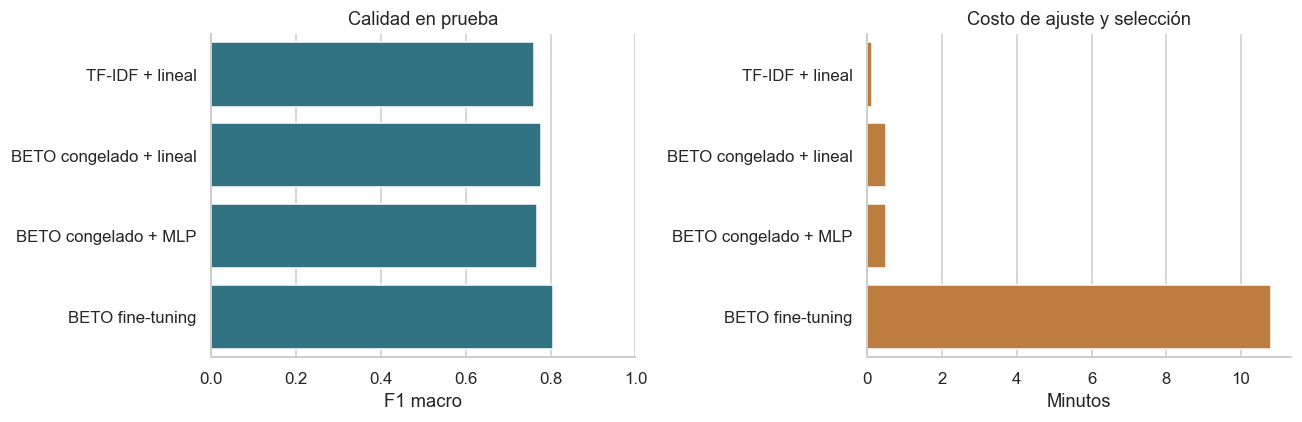

In [13]:
probabilities, inference_seconds = {}, {}
start = time.perf_counter()
probabilities["TF-IDF + lineal"] = tfidf.predict_proba(clean["test"].utt)
inference_seconds["TF-IDF + lineal"] = time.perf_counter()-start
assert np.array_equal(tfidf.classes_, np.arange(N_CLASSES))

# Volvemos a cargar el extractor base. Ningún parámetro se ajusta con prueba.
encoder = AutoModel.from_pretrained(BASE, local_files_only=True, add_pooling_layer=False).to(DEVICE)
encoder.eval()
start = time.perf_counter()
embeddings["test"] = extraer_vectores(clean["test"].utt.tolist())
sincronizar()
test_extraction_seconds = time.perf_counter()-start
for name, head in heads.items():
    start = time.perf_counter()
    probabilities[name] = probabilidades_cabeza(head, embeddings["test"])
    inference_seconds[name] = test_extraction_seconds + time.perf_counter()-start

start = time.perf_counter()
tokenized["test"] = tokenizar_particion("test")
fine_test = trainer.predict(cast(Any, tokenized["test"]))
sincronizar()
inference_seconds["BETO fine-tuning"] = time.perf_counter()-start
probabilities["BETO fine-tuning"] = torch.softmax(torch.tensor(fine_test.predictions), -1).numpy()

predictions = {name: probs.argmax(1) for name, probs in probabilities.items()}
results = pd.DataFrame([{"modelo": name, **metricas(y["test"], pred),
                         "minutos_ajuste": training_cost[name]/60,
                         "segundos_predicción_prueba": inference_seconds[name]}
                        for name, pred in predictions.items()])
results.to_csv(OUT / "comparacion_prueba.csv", index=False)
np.savez_compressed(OUT / "probabilidades_prueba.npz", **{f"modelo_{i}": p for i,p in enumerate(probabilities.values())})
display(results.round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=results, x="f1_macro", y="modelo", ax=axes[0], color="#247B91")
axes[0].set(xlim=(0,1), xlabel="F1 macro", ylabel="", title="Calidad en prueba")
sns.barplot(data=results, x="minutos_ajuste", y="modelo", ax=axes[1], color="#D27C2C")
axes[1].set(xlabel="Minutos", ylabel="", title="Costo de ajuste y selección")
plt.tight_layout(); guardar_figura("comparacion_modelos")

## 11. Resultados por intención y análisis de errores

Una puntuación global no explica dónde falla el asistente. Examinamos el modelo
elegido por validación, incluso si otra alternativa obtiene mayor puntuación en prueba.
El soporte indica cuántos ejemplos respaldan cada medida. Nos interesan especialmente
confusiones entre consultar, crear, modificar y eliminar.

,precision,recall,f1-score,support
iot_hue_lighton,0.000,0.000,0.000,3.0
music_dislikeness,0.000,0.000,0.000,4.0
general_greet,0.000,0.000,0.000,1.0
music_settings,0.167,0.167,0.167,6.0
audio_volume_other,1.000,0.333,0.500,6.0
general_quirky,0.702,0.627,0.662,169.0
datetime_convert,0.889,0.533,0.667,15.0
email_addcontact,0.588,0.833,0.690,12.0
audio_volume_up,0.667,0.769,0.714,13.0
play_game,0.833,0.714,0.769,35.0


,precision,recall,f1-score,support
cooking_query,NaN,NaN,NaN,0.0


,real,predicha,casos
42,general_quirky,qa_factoid,11
35,general_quirky,news_query,10
117,play_radio,play_music,10
38,general_quirky,calendar_query,9
178,calendar_set,calendar_query,8
185,play_game,play_music,7
107,calendar_query,calendar_set,7
163,qa_factoid,general_quirky,6
118,datetime_convert,datetime_query,5
76,news_query,general_quirky,5


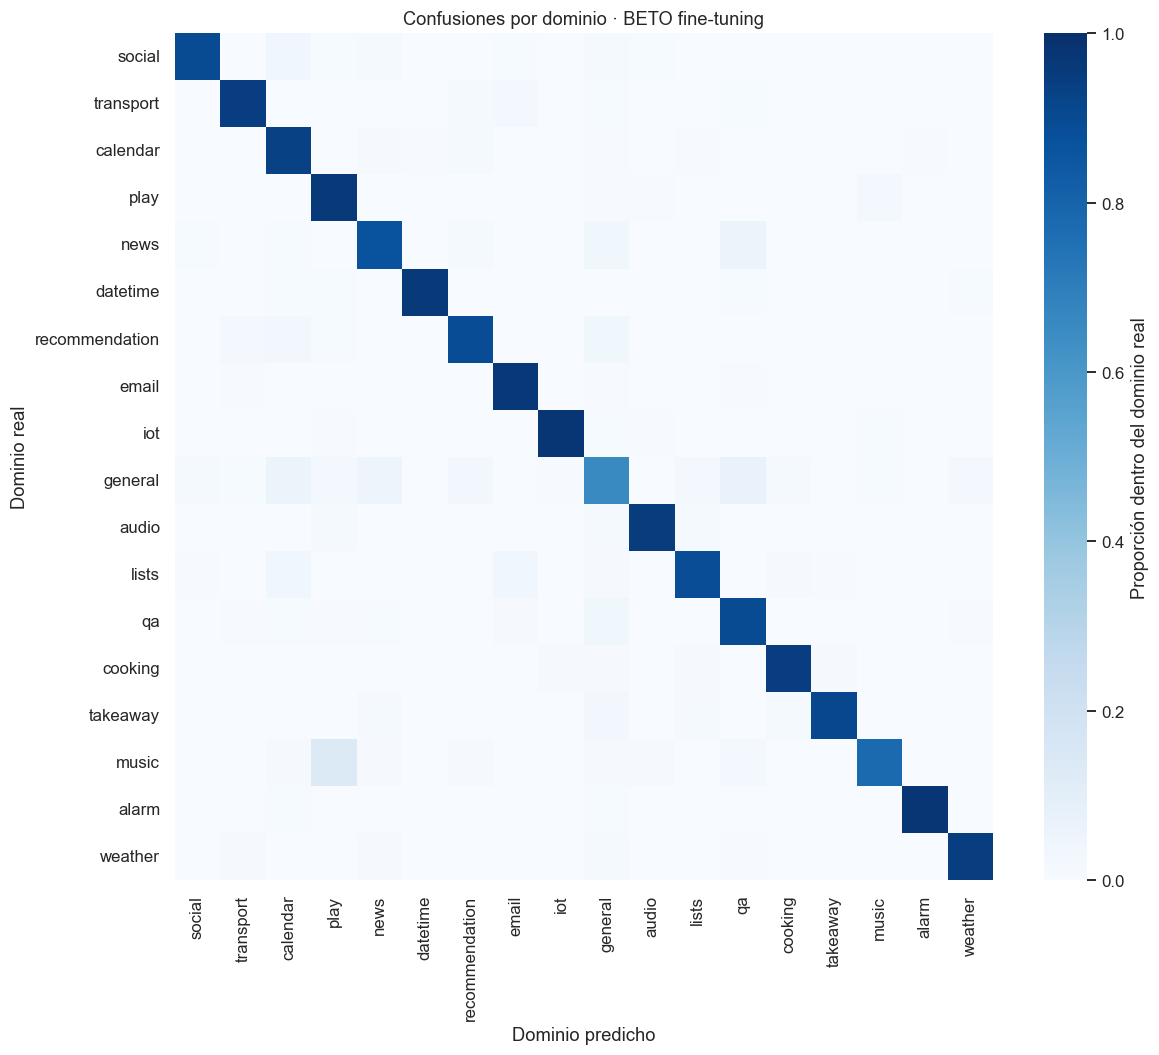

,id,utt,intencion,predicción,puntuación_máxima
1295,7353,solo hazme saber el tiempo de las próximas semanas en california,email_query,weather_query,0.992322
2389,13888,cuál es la temperatura en barcelona cataluña,qa_factoid,weather_query,0.990286
2557,14877,cuáles son las condiciones climáticas en esa zona,qa_factoid,weather_query,0.990120
1137,6473,el tiempo estuvo mal hoy,general_quirky,weather_query,0.989636
1374,7894,dame una actualización sobre las elecciones en una hora,calendar_set,news_query,0.988717
1564,9035,recordatorio boda raúl,calendar_query,calendar_set,0.986434
1839,10525,quita mi pago del coche en mi calendario,lists_remove,calendar_remove,0.985154
1364,7851,tengo una reunión hoy al mediodía,calendar_set,calendar_query,0.984995
1581,9124,enséñame los eventos de mi calendario del trabajo para la próxima semana,calendar_set,calendar_query,0.983905
1482,8525,recordatorios de reuniones desde las tres a las cinco,calendar_query,calendar_set,0.983818


El modelo seleccionado fue **BETO fine-tuning**. Cometió **390 errores en 2974 solicitudes**. Los errores de puntuación alta son útiles para revisar ambigüedad y etiquetas; muestran que una puntuación alta no garantiza un acierto.

In [14]:
chosen_pred = predictions[winner_name]
chosen_probs = probabilities[winner_name]
report = pd.DataFrame(classification_report(y["test"], chosen_pred, labels=range(N_CLASSES),
                     target_names=LABELS, output_dict=True, zero_division=0)).T.loc[LABELS]
report.loc[report.support == 0, ["precision", "recall", "f1-score"]] = np.nan
report.to_csv(OUT / "reporte_por_intencion.csv")
display(report.sort_values("f1-score").head(15).round(3))
display(report.loc[report.support == 0])
cm = confusion_matrix(y["test"], chosen_pred, labels=range(N_CLASSES))
pd.DataFrame(cm, index=LABELS, columns=LABELS).to_csv(OUT / "matriz_confusion_completa.csv")
off_diagonal = cm.copy(); np.fill_diagonal(off_diagonal, 0)
pairs = [(LABELS[i], LABELS[j], int(off_diagonal[i,j]))
         for i,j in zip(*np.where(off_diagonal > 0))]
confusions = pd.DataFrame(pairs, columns=["real", "predicha", "casos"]).sort_values("casos", ascending=False)
confusions.to_csv(OUT / "confusiones.csv", index=False)
display(confusions.head(12))

# Matriz por los 18 dominios para una vista legible; la de 60 intenciones se exporta completa.
intent_to_domain = train_df.groupby("intent").scenario.first().to_dict()
assert train_df.groupby("intent").scenario.nunique().max() == 1
true_domains = np.array([intent_to_domain[int(i)] for i in y["test"]])
pred_domains = np.array([intent_to_domain[int(i)] for i in chosen_pred])
domain_cm = confusion_matrix(true_domains, pred_domains, labels=range(len(SCENARIOS)), normalize="true")
plt.figure(figsize=(12, 10))
sns.heatmap(domain_cm, xticklabels=SCENARIOS, yticklabels=SCENARIOS, cmap="Blues", vmin=0,vmax=1,
            cbar_kws={"label": "Proporción dentro del dominio real"})
plt.xlabel("Dominio predicho"); plt.ylabel("Dominio real")
plt.title(f"Confusiones por dominio · {winner_name}")
guardar_figura("matriz_dominios")

error_table = clean["test"][["id", "utt", "intencion"]].copy()
error_table["predicción"] = [id2label[int(i)] for i in chosen_pred]
error_table["puntuación_máxima"] = chosen_probs.max(1)
error_table["correcta"] = chosen_pred == y["test"]
error_table.to_csv(OUT / "predicciones_prueba.csv", index=False)
errors = error_table.loc[~error_table.correcta].sort_values("puntuación_máxima", ascending=False)
display(errors.head(12).drop(columns="correcta"))
display(Markdown(f"El modelo seleccionado fue **{winner_name}**. Cometió **{len(errors)} errores "
                 f"en {len(error_table)} solicitudes**. Los errores de puntuación alta son útiles "
                 "para revisar ambigüedad y etiquetas; muestran que una puntuación alta no garantiza un acierto."))

### Lectura de algunos errores de la ejecución entregada

Las confusiones frecuentes no se reparten al azar. `general_quirky` reúne solicitudes
variadas y se confunde con preguntas de hechos, noticias y calendario. También vemos
fronteras cercanas entre `play_radio` y `play_music`, y entre crear y consultar eventos.

Hay casos que merecen revisar la anotación. «cuál es la temperatura en barcelona
cataluña» tiene etiqueta `qa_factoid`, pero el modelo predice `weather_query`. En
«solo hazme saber el tiempo de las próximas semanas en california», la etiqueta es
`email_query` y la predicción también es `weather_query`. A partir del texto aislado,
la predicción parece razonable. Podría existir contexto ausente o una etiqueta
discutible; no podemos resolverlo automáticamente. Conservamos las etiquetas originales
para medir y distinguimos un desacuerdo con la etiqueta de un error evidente de comprensión.

En cambio, «dame una actualización sobre las elecciones en una hora», etiquetado
`calendar_set`, fue interpretado como `news_query`. Aquí el tema de las elecciones
puede dominar la señal temporal «en una hora». Estos ejemplos sugieren evaluar mejor
la diferencia entre el tema del texto y la acción que se pide.

## 12. Aporte práctico: decidir cuándo pedir una aclaración

Un asistente puede abstenerse cuando sus puntuaciones son bajas. Para ilustrarlo,
probamos umbrales sobre la puntuación máxima de validación y buscamos la mayor cobertura
que alcance al menos 90 % de aciertos entre los casos aceptados, con un mínimo de 50 casos.
Si ninguno alcanza la meta, lo indicamos y conservamos la clasificación sin abstención.
El umbral se fija antes de medir su resultado en prueba.

Estas puntuaciones **no están calibradas**: 0,90 no debe leerse automáticamente como
90 % de probabilidad de acertar. Tampoco este umbral demuestra detección de solicitudes
fuera de las 60 categorías. Para eso necesitaríamos un conjunto de evaluación específico.

,umbral,meta_validacion_alcanzada,cobertura_prueba,solicitudes_aceptadas,accuracy_aceptadas_prueba
0,0.55,True,0.937122,2787,0.902404


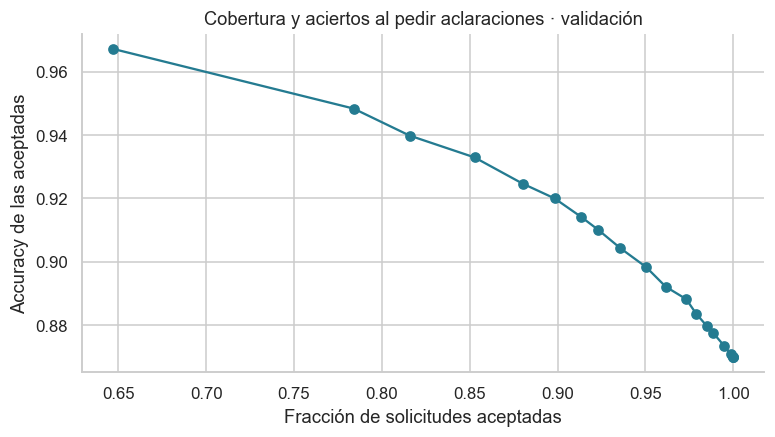

In [15]:
def probabilidades_textos(texts, name=winner_name):
    if name == "TF-IDF + lineal":
        return tfidf.predict_proba(texts)
    if name in heads:
        return probabilidades_cabeza(heads[name], extraer_vectores(texts))
    fine_model.eval()
    output = []
    with torch.inference_mode():
        for i in range(0, len(texts), 32):
            encoded = tokenizer(texts[i:i+32], padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt")
            encoded = {k:v.to(fine_model.device) for k,v in encoded.items()}
            output.append(torch.softmax(fine_model(**encoded).logits, dim=-1).cpu().numpy())
    return np.concatenate(output)

accepted = chosen_probs.max(1) >= THRESHOLD
selective = {"umbral": THRESHOLD, "meta_validacion_alcanzada": bool(len(eligible)),
             "cobertura_prueba": float(accepted.mean()), "solicitudes_aceptadas": int(accepted.sum()),
             "accuracy_aceptadas_prueba": float(accuracy_score(y["test"][accepted], chosen_pred[accepted])) if accepted.any() else None}
(OUT / "abstencion.json").write_text(json.dumps(selective, indent=2))
display(pd.DataFrame([selective]))
plt.figure(figsize=(8,4))
plt.plot(threshold_table.cobertura, threshold_table.accuracy_aceptados, marker="o", color="#247B91")
plt.xlabel("Fracción de solicitudes aceptadas"); plt.ylabel("Accuracy de las aceptadas")
plt.title("Cobertura y aciertos al pedir aclaraciones · validación")
guardar_figura("cobertura_aciertos")

## 13. Demostración y prueba de robustez

Las siguientes frases son ejemplos manuales nuevos. Definimos las etiquetas esperadas
antes de predecir. Formamos pares con cambios de escritura y expresiones colombianas
para observar si se conserva la intención. La muestra es pequeña y deliberada: sirve
para inspección, **no para estimar el desempeño en Colombia**. No la usamos para
volver a entrenar ni escoger el modelo.

In [16]:
manual = pd.DataFrame([
    ("Alarma", "normal", "Pon una alarma para mañana a las siete", "alarm_set"),
    ("Alarma", "variante", "pon una alrma pa mañana a las siete", "alarm_set"),
    ("Clima", "normal", "¿Cómo estará el clima mañana en Cali?", "weather_query"),
    ("Clima", "variante", "¿Mañana va a llover por acá en Cali?", "weather_query"),
    ("Música", "normal", "Reproduce música de salsa", "play_music"),
    ("Música", "variante", "Parce, poneme una salsita", "play_music"),
    ("Calendario", "normal", "¿Qué reuniones tengo mañana?", "calendar_query"),
    ("Calendario", "variante", "qué reunions tengo pa mañana", "calendar_query"),
    ("Taxi", "normal", "Pide un taxi para ir al aeropuerto", "transport_taxi"),
    ("Taxi", "variante", "Pedime un taxi pa ir al aeropuerto", "transport_taxi"),
    ("Luz", "normal", "Apaga la luz de la sala", "iot_hue_lightoff"),
    ("Luz", "variante", "Haceme el favor y apagá la luz de la sala", "iot_hue_lightoff"),
], columns=["par", "tipo", "texto", "esperada"])
manual_probs = probabilidades_textos(manual.texto.tolist())
manual["predicha"] = [id2label[int(i)] for i in manual_probs.argmax(1)]
manual["puntuación"] = manual_probs.max(1)
manual["correcta"] = manual.esperada == manual.predicha
manual["pedir_aclaración"] = manual.puntuación < THRESHOLD
manual.to_csv(OUT / "prueba_manual.csv", index=False)
display(manual)
display(manual.groupby("tipo").correcta.agg(["sum", "count", "mean"]))

def clasificar_solicitud(texto):
    if not isinstance(texto, str) or not texto.strip():
        raise ValueError("Escribe una solicitud con contenido.")
    probs = probabilidades_textos([texto])[0]
    indices = probs.argsort()[-3:][::-1]
    print("Solicitud:", texto)
    print("Decisión:", "Pedir una aclaración" if probs.max() < THRESHOLD else "Proponer la intención más probable")
    return pd.DataFrame({"intención": [id2label[int(i)] for i in indices], "puntuación": probs[indices]})

display(clasificar_solicitud("Recuérdame la reunión de mañana a las nueve"))

,par,tipo,texto,esperada,predicha,puntuación,correcta,pedir_aclaración
0,Alarma,normal,Pon una alarma para mañana a las siete,alarm_set,alarm_set,0.974748,True,False
1,Alarma,variante,pon una alrma pa mañana a las siete,alarm_set,calendar_set,0.812471,False,False
2,Clima,normal,¿Cómo estará el clima mañana en Cali?,weather_query,weather_query,0.992003,True,False
3,Clima,variante,¿Mañana va a llover por acá en Cali?,weather_query,weather_query,0.991094,True,False
4,Música,normal,Reproduce música de salsa,play_music,play_music,0.970730,True,False
5,Música,variante,"Parce, poneme una salsita",play_music,play_music,0.869181,True,False
6,Calendario,normal,¿Qué reuniones tengo mañana?,calendar_query,calendar_query,0.985822,True,False
7,Calendario,variante,qué reunions tengo pa mañana,calendar_query,calendar_query,0.987032,True,False
8,Taxi,normal,Pide un taxi para ir al aeropuerto,transport_taxi,transport_taxi,0.959445,True,False
9,Taxi,variante,Pedime un taxi pa ir al aeropuerto,transport_taxi,transport_taxi,0.960550,True,False


,sum,count,mean
tipo,,,
normal,6,6,1.000000
variante,5,6,0.833333


Solicitud: Recuérdame la reunión de mañana a las nueve
Decisión: Proponer la intención más probable


,intención,puntuación
0,calendar_set,0.992033
1,calendar_query,0.001297
2,alarm_set,0.000968


**Lectura de la prueba manual.** En la ejecución entregada se acertaron los seis textos
normales y cinco de las seis variantes. «pon una alrma pa mañana a las siete» cambió
de `alarm_set` a `calendar_set`, con puntuación aproximada de 0,812, superior al umbral
de 0,55. La regla de aclaración no detuvo ese error. En cambio, «Parce, poneme una
salsita» conservó `play_music`. Estos casos muestran que la robustez depende de la
expresión concreta; doce ejemplos no bastan para concluir que el modelo entiende
de manera general el habla colombiana.

Puedes cambiar el texto de la siguiente celda. Las tres alternativas ayudan a observar
ambigüedad; no son respuestas del asistente ni acciones ejecutadas.

In [17]:
display(clasificar_solicitud("¿Qué alarmas tengo programadas?"))

Solicitud: ¿Qué alarmas tengo programadas?
Decisión: Proponer la intención más probable


,intención,puntuación
0,alarm_query,0.971057
1,alarm_set,0.002749
2,transport_traffic,0.001970


## 14. Conclusiones a partir de esta ejecución

La siguiente celda resume los resultados calculados. Distinguimos las mejoras observadas de explicaciones posibles.

In [18]:
indexed = results.set_index("modelo")
base_f1 = cast(float, indexed.loc["TF-IDF + lineal", "f1_macro"])
fine_f1 = cast(float, indexed.loc["BETO fine-tuning", "f1_macro"])
frozen_linear = cast(float, indexed.loc["BETO congelado + lineal", "f1_macro"])
frozen_mlp = cast(float, indexed.loc["BETO congelado + MLP", "f1_macro"])
delta_data = cast(float, learning_table.iloc[-1].f1_macro) - cast(float, learning_table.iloc[0].f1_macro)
top_confusion = confusions.iloc[0] if len(confusions) else None
summary = f"""### Resultados y conclusiones

- **Selección:** elegimos {winner_name} por F1 macro de validación. En prueba obtuvo
  F1 macro de {indexed.loc[winner_name, 'f1_macro']:.3f} y accuracy de {indexed.loc[winner_name, 'accuracy']:.3f}.
- **Referencia frente a ajuste completo:** TF-IDF alcanzó {base_f1:.3f} de F1 macro y BETO
  ajustado {fine_f1:.3f}. La diferencia observada fue de {(fine_f1-base_f1)*100:+.2f} puntos porcentuales.
  TF-IDF sigue siendo una referencia útil por su sencillez y costo.
- **Capacidad de la cabeza:** la cabeza lineal congelada obtuvo {frozen_linear:.3f} y la MLP
  {frozen_mlp:.3f}. La diferencia de {(frozen_mlp-frozen_linear)*100:+.2f} puntos corresponde a esta
  configuración y semilla; una cabeza más grande no garantiza una mejora general.
- **Cantidad de datos:** pasar del 25 % al 100 % del entrenamiento cambió el F1 macro
  de validación de TF-IDF en {delta_data*100:+.2f} puntos. La curva permite contrastar nuestra
  idea inicial sobre el valor de disponer de más ejemplos.
- **Costo:** el fine-tuning requirió {indexed.loc['BETO fine-tuning','minutos_ajuste']:.1f} minutos
  de ajuste y selección en este equipo. Es un costo medido, no una estimación para otros computadores.
- **Uso práctico:** el umbral elegido en validación fue {THRESHOLD:.2f}; en prueba aceptó
  {selective['cobertura_prueba']:.1%} de las solicitudes. Debe interpretarse junto con los
  aciertos entre aceptadas y los casos enviados a aclaración.

### Límites y siguientes pasos

Ejecutamos una semilla y un presupuesto acotado. No afirmamos superioridad estadística
sin repetir experimentos. El español de España y el formato de solicitudes aisladas
limitan la transferencia a usuarios colombianos, conversaciones largas y tareas nuevas.
Los ejemplos manuales muestran casos, no validan un despliegue. La auditoría evita
duplicados exactos entre particiones, pero no elimina toda semejanza semántica.

Antes de usarlo en un asistente real, recogeríamos solicitudes locales etiquetadas,
evaluaríamos fuera de dominio y calibración, repetiríamos semillas y añadiríamos
extracción de parámetros. Una clasificación correcta por sí sola no basta para ejecutar
una acción de manera fiable.

Las tablas, gráficas y predicciones se guardan en `resultados/`.
"""
if top_confusion is not None:
    summary += f"\nLa confusión más frecuente fue **{top_confusion['real']} → {top_confusion['predicha']}**, "
    summary += f"con **{top_confusion['casos']} casos**. Debe revisarse junto con sus textos y soportes.\n"
display(Markdown(summary))

configuration = {"seed": SEED, "max_length": MAX_LEN, "winner": winner_name, "threshold": THRESHOLD,
                 "labels": LABELS, "dataset_revision": manifest["dataset_revision"],
                 "model_revision": manifest["model_revision"], "epochs_fine": EPOCHS_FINE,
                 "batch_fine": BATCH_FINE, "learning_rate_fine": 3e-5,
                 "training_sizes": {s:len(clean[s]) for s in clean}}
_ = (OUT / "configuracion.json").write_text(json.dumps(configuration, ensure_ascii=False, indent=2))


### Resultados y conclusiones

- **Selección:** elegimos BETO fine-tuning por F1 macro de validación. En prueba obtuvo
  F1 macro de 0.805 y accuracy de 0.869.
- **Referencia frente a ajuste completo:** TF-IDF alcanzó 0.760 de F1 macro y BETO
  ajustado 0.805. La diferencia observada fue de +4.44 puntos porcentuales.
  TF-IDF sigue siendo una referencia útil por su sencillez y costo.
- **Capacidad de la cabeza:** la cabeza lineal congelada obtuvo 0.777 y la MLP
  0.769. La diferencia de -0.84 puntos corresponde a esta
  configuración y semilla; una cabeza más grande no garantiza una mejora general.
- **Cantidad de datos:** pasar del 25 % al 100 % del entrenamiento cambió el F1 macro
  de validación de TF-IDF en +12.29 puntos. La curva permite contrastar nuestra
  idea inicial sobre el valor de disponer de más ejemplos.
- **Costo:** el fine-tuning requirió 10.8 minutos
  de ajuste y selección en este equipo. Es un costo medido, no una estimación para otros computadores.
- **Uso práctico:** el umbral elegido en validación fue 0.55; en prueba aceptó
  93.7% de las solicitudes. Debe interpretarse junto con los
  aciertos entre aceptadas y los casos enviados a aclaración.

### Límites y siguientes pasos

Ejecutamos una semilla y un presupuesto acotado. No afirmamos superioridad estadística
sin repetir experimentos. El español de España y el formato de solicitudes aisladas
limitan la transferencia a usuarios colombianos, conversaciones largas y tareas nuevas.
Los ejemplos manuales muestran casos, no validan un despliegue. La auditoría evita
duplicados exactos entre particiones, pero no elimina toda semejanza semántica.

Antes de usarlo en un asistente real, recogeríamos solicitudes locales etiquetadas,
evaluaríamos fuera de dominio y calibración, repetiríamos semillas y añadiríamos
extracción de parámetros. Una clasificación correcta por sí sola no basta para ejecutar
una acción de manera fiable.

Las tablas, gráficas y predicciones se guardan en `resultados/`.

La confusión más frecuente fue **general_quirky → qa_factoid**, con **11 casos**. Debe revisarse junto con sus textos y soportes.


## 15. Referencias

- FitzGerald et al. (2022). [MASSIVE: A 1M-Example Multilingual Natural Language Understanding Dataset](https://arxiv.org/abs/2204.08582).
- Amazon Science. [Dataset MASSIVE y licencia CC BY 4.0](https://huggingface.co/datasets/AmazonScience/massive).
- Cañete et al. (2020). [BETO: Spanish BERT](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased).
- Hugging Face. [Trainer, versión 4.46.3](https://huggingface.co/docs/transformers/v4.46.3/en/main_classes/trainer).
- [Notebook de referencia de la clase](https://github.com/Ohtar10/icesi-advanced-dl/blob/main/Unidad%203%20-%20Transformers/text-classification-with-hf.ipynb).
